## ============================================================
## Notebook: 04_clv_analysis.ipynb
## ============================================================

### =========================
### 1. IMPORT LIBRARIES
### =========================

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.utils import summary_data_from_transaction_data

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")

print("✅ Libraries imported")

✅ Libraries imported


### =========================
### 2. LOAD DATA
### =========================

In [2]:
df = pd.read_csv('../data/processed/cleaned_transactions.csv', parse_dates=['invoicedate'])

print(f"Loaded {len(df):,} transactions")
print(f"Unique customers: {df['customer_id'].nunique():,}")
print(f"Date range: {df['invoicedate'].min()} to {df['invoicedate'].max()}")

Loaded 779,425 transactions
Unique customers: 5,878
Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00


### =========================
### 3. Prepare Data for CLV Model
### =========================

In [3]:
# Prepare data for lifetimes library
summary = summary_data_from_transaction_data(
    df, 
    'customer_id', 
    'invoicedate', 
    'total_price', 
    observation_period_end=df['invoicedate'].max()
)

In [4]:
summary.reset_index(inplace=True)
summary.columns = ['customer_id', 'frequency', 'recency', 'T', 'monetary_value']

# Filter out customers with negative or zero monetary value
summary = summary[summary['monetary_value'] > 0]
summary = summary[summary['frequency'] > 0]



In [5]:
print(f"CLV dataset shape: {summary.shape}")
print(f"Average frequency: {summary['frequency'].mean():.2f}")
print(f"Average recency: {summary['recency'].mean():.2f}")
print(f"Average monetary: ${summary['monetary_value'].mean():.2f}")

CLV dataset shape: (4189, 5)
Average frequency: 6.50
Average recency: 383.63
Average monetary: $439.20


### ============================
### 4. Fit BG/NBD Model (Frequency/Recency)
### ============================

In [6]:
# Fit BG/NBD model
bgf = BetaGeoFitter(penalizer_coef=0.0)
bgf.fit(summary['frequency'], summary['recency'], summary['T'])


<lifetimes.BetaGeoFitter: fitted with 4189 subjects, a: 0.10, alpha: 104.62, b: 1.12, r: 1.54>

In [7]:
print("BG/NBD Model Fitted")
print(f"Model parameters:")
print(f"  r: {bgf.params_['r']:.4f}")
print(f"  alpha: {bgf.params_['alpha']:.4f}")
print(f"  a: {bgf.params_['a']:.4f}")
print(f"  b: {bgf.params_['b']:.4f}")

BG/NBD Model Fitted
Model parameters:
  r: 1.5369
  alpha: 104.6241
  a: 0.1050
  b: 1.1173


### =========================
### 5. Predict Future Transactions
### =========================

In [8]:
#Predict future transactions for next 12 months
t = 12  # months
summary['predicted_purchases_12m'] = bgf.conditional_expected_number_of_purchases_up_to_time(
    t, summary['frequency'], summary['recency'], summary['T']
)

print(f"Predicted purchases next 12 months - summary:")
print(summary['predicted_purchases_12m'].describe())

Predicted purchases next 12 months - summary:
count    4.189000e+03
mean     1.386798e-01
std      1.745348e-01
min      5.060776e-10
25%      4.880937e-02
50%      9.716371e-02
75%      1.748547e-01
max      3.634406e+00
Name: predicted_purchases_12m, dtype: float64


### ==============================
### 6. Fit Gamma-Gamma Model (Monetary Value)
### ==============================

In [9]:
# Fit Gamma-Gamma model for monetary value
ggf = GammaGammaFitter(penalizer_coef=0.0)
ggf.fit(summary['frequency'], summary['monetary_value'])

print("Gamma-Gamma Model Fitted")
print(f"Model parameters:")
print(f"  p: {ggf.params_['p']:.4f}")
print(f"  q: {ggf.params_['q']:.4f}")
print(f"  v: {ggf.params_['v']:.4f}")

Gamma-Gamma Model Fitted
Model parameters:
  p: 2.1743
  q: 3.4842
  v: 457.4368


### =============================
### 7. Calculate Customer Lifetime Value
### =============================

In [10]:
# Calculate CLV for next 12 months
discount_rate = 0.01  # 1% monthly discount rate
summary['clv_12m'] = ggf.customer_lifetime_value(
    bgf,
    summary['frequency'],
    summary['recency'],
    summary['T'],
    summary['monetary_value'],
    time=12,
    discount_rate=discount_rate
)

In [11]:
print(f"CLV (12 months) statistics:")
print(summary['clv_12m'].describe())
print(f"\nTotal predicted CLV: ${summary['clv_12m'].sum():,.2f}")

CLV (12 months) statistics:
count      4189.000000
mean       1896.125060
std        7466.912955
min           0.000002
25%         406.447612
50%         863.254833
75%        1744.777448
max      228528.085912
Name: clv_12m, dtype: float64

Total predicted CLV: $7,942,867.88


### =========================
### 8. Segment Customers by CLV
### =========================

In [12]:
# Create CLV segments
summary['clv_segment'] = pd.qcut(summary['clv_12m'], q=4, labels=['Low', 'Medium-Low', 'Medium-High', 'High'])

clv_segment_summary = summary.groupby('clv_segment').agg({
    'customer_id': 'count',
    'clv_12m': ['mean', 'sum'],
    'frequency': 'mean',
    'monetary_value': 'mean'
}).round(2)


In [13]:
clv_segment_summary.columns = ['count', 'avg_clv', 'total_clv', 'avg_frequency', 'avg_monetary']
clv_segment_summary['pct_of_customers'] = (clv_segment_summary['count'] / clv_segment_summary['count'].sum() * 100).round(1)
clv_segment_summary['pct_of_value'] = (clv_segment_summary['total_clv'] / clv_segment_summary['total_clv'].sum() * 100).round(1)

print("CLV Segmentation:")
print(clv_segment_summary)

CLV Segmentation:
             count  avg_clv   total_clv  avg_frequency  avg_monetary  \
clv_segment                                                            
Low           1048   214.36   224650.08           2.27        260.43   
Medium-Low    1047   608.99   637614.51           3.10        285.93   
Medium-High   1047  1238.20  1296399.55           5.50        356.22   
High          1047  5524.55  5784203.74          15.13        854.38   

             pct_of_customers  pct_of_value  
clv_segment                                  
Low                      25.0           2.8  
Medium-Low               25.0           8.0  
Medium-High              25.0          16.3  
High                     25.0          72.8  


### ===========================
### 9. Visualize CLV Distribution
### ===========================

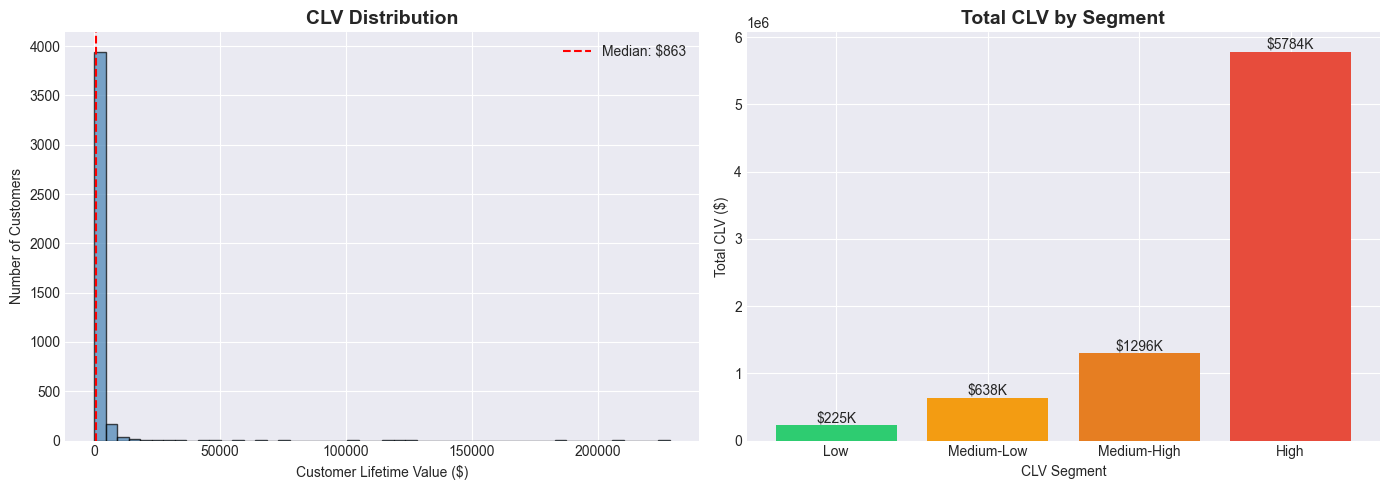

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CLV distribution histogram
axes[0].hist(summary['clv_12m'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Customer Lifetime Value ($)')
axes[0].set_ylabel('Number of Customers')
axes[0].set_title('CLV Distribution', fontsize=14, fontweight='bold')
axes[0].axvline(x=summary['clv_12m'].median(), color='red', linestyle='--', label=f'Median: ${summary["clv_12m"].median():,.0f}')
axes[0].legend()

# CLV by segment bar chart
colors = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c']
bars = axes[1].bar(clv_segment_summary.index, clv_segment_summary['total_clv'], color=colors)
axes[1].set_xlabel('CLV Segment')
axes[1].set_ylabel('Total CLV ($)')
axes[1].set_title('Total CLV by Segment', fontsize=14, fontweight='bold')

# Add value labels
for bar, value in zip(bars, clv_segment_summary['total_clv']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'${value/1000:.0f}K', 
                 ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('../reports/clv_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### =========================
### 10. Top Customers by CLV
### =========================

In [15]:
top_clv = summary.nlargest(20, 'clv_12m')[['customer_id', 'clv_12m', 'frequency', 'recency', 'monetary_value', 'predicted_purchases_12m']]

print("Top 20 Customers by Predicted CLV:")
print(top_clv.to_string(index=False))

Top 20 Customers by Predicted CLV:
 customer_id       clv_12m  frequency  recency  monetary_value  predicted_purchases_12m
       18102 228528.085912       66.0    738.0     8768.193939                 0.959556
       14646 206507.469428       90.0    736.0     5809.905333                 1.302470
       16446 186904.686598        1.0    205.0   168469.600000                 0.089593
       17450 125362.132741       30.0    430.0     6851.561667                 0.692738
       14156 122934.271529      120.0    729.0     2603.090167                 1.723978
       14911 114533.316446      254.0    737.0     1144.437717                 3.634406
       14096 102454.862204       16.0     97.0     4071.434375                 1.010846
       13694  76555.988829       82.0    732.0     2355.009756                 1.190961
       12415  74645.574068       22.0    503.0     6460.528636                 0.441487
       17511  67016.357138       50.0    735.0     3380.484600                 0.7325

### =========================
### 11. Business Recommendations
### =========================

In [16]:
print("=" * 60)
print("BUSINESS RECOMMENDATIONS FROM CLV ANALYSIS")
print("=" * 60)

high_value_customers = summary[summary['clv_segment'] == 'High']
print(f"\n📊 KEY INSIGHTS:")
print(f"   • High CLV customers ({len(high_value_customers)} customers) represent {clv_segment_summary.loc['High', 'pct_of_value']:.1f}% of total predicted value")
print(f"   • Average CLV of High segment: ${high_value_customers['clv_12m'].mean():,.2f}")
print(f"   • Average CLV of Low segment: ${summary[summary['clv_segment'] == 'Low']['clv_12m'].mean():,.2f}")

print(f"\n🎯 RECOMMENDED ACTIONS:")
print(f"   1. Allocate 50% of marketing budget to retain High CLV customers")
print(f"   2. Develop upsell/cross-sell campaigns for Medium-High segment")
print(f"   3. Test lower-cost retention strategies for Medium-Low segment")
print(f"   4. Consider deprioritizing Low segment marketing spend")

print(f"\n💰 PROJECTED FINANCIAL IMPACT:")
print(f"   • Total predicted CLV across all customers: ${summary['clv_12m'].sum():,.2f}")
print(f"   • High segment contributes: ${clv_segment_summary.loc['High', 'total_clv']:,.2f}")

BUSINESS RECOMMENDATIONS FROM CLV ANALYSIS

📊 KEY INSIGHTS:
   • High CLV customers (1047 customers) represent 72.8% of total predicted value
   • Average CLV of High segment: $5,524.55
   • Average CLV of Low segment: $214.36

🎯 RECOMMENDED ACTIONS:
   1. Allocate 50% of marketing budget to retain High CLV customers
   2. Develop upsell/cross-sell campaigns for Medium-High segment
   3. Test lower-cost retention strategies for Medium-Low segment
   4. Consider deprioritizing Low segment marketing spend

💰 PROJECTED FINANCIAL IMPACT:
   • Total predicted CLV across all customers: $7,942,867.88
   • High segment contributes: $5,784,203.74


### =========================
### 12. Save Results
### =========================

In [17]:
summary.to_csv('../data/processed/customer_clv.csv', index=False)
print("✅ CLV results saved to '../data/processed/customer_clv.csv'")

✅ CLV results saved to '../data/processed/customer_clv.csv'
